# EDA for all data

### imports and config

In [25]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from training.dataset.load import load_all_data

## 1. Structure

In [ ]:
df = load_all_data()
print(df.shape)

(14412, 2)


In [6]:
print(df.isnull().sum()) # Missing values

text     0
label    0
dtype: int64


In [5]:
print(f"\nDtypes:\n{df.dtypes}")


Dtypes:
text       str
label    int64
dtype: object


## 2. Class balance

In [14]:
print("Label distribution:")
print(df["label"].value_counts())
print(f"\nIn percent:")
print(df["label"].value_counts(normalize=True))

Label distribution:
label
0    9586
1    4826
Name: count, dtype: int64

In percent:
label
0    0.66514
1    0.33486
Name: proportion, dtype: float64


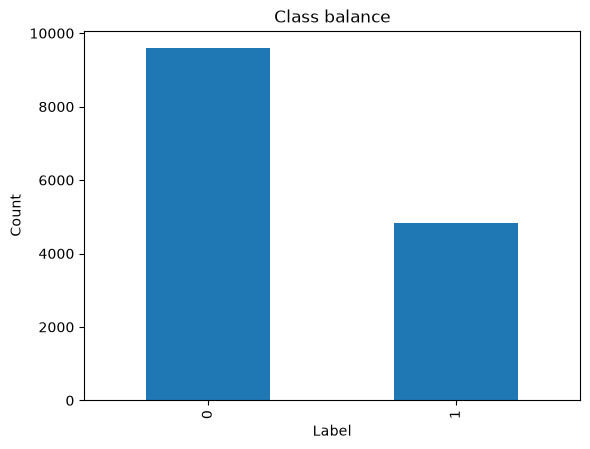

In [13]:
df["label"].value_counts().plot(kind="bar", title="Class balance")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 3. Text length

In [18]:
df["length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Character length:")
print(df["length"].describe())

print("\nWord count:")
print(df["word_count"].describe())

Character length:
count    14412.000000
mean       176.525812
std        271.612376
min         21.000000
25%         57.000000
50%        101.000000
75%        197.000000
max       7404.000000
Name: length, dtype: float64

Word count:
count    14412.000000
mean        27.946017
std         41.432218
min          1.000000
25%          9.000000
50%         16.000000
75%         32.000000
max       1078.000000
Name: word_count, dtype: float64


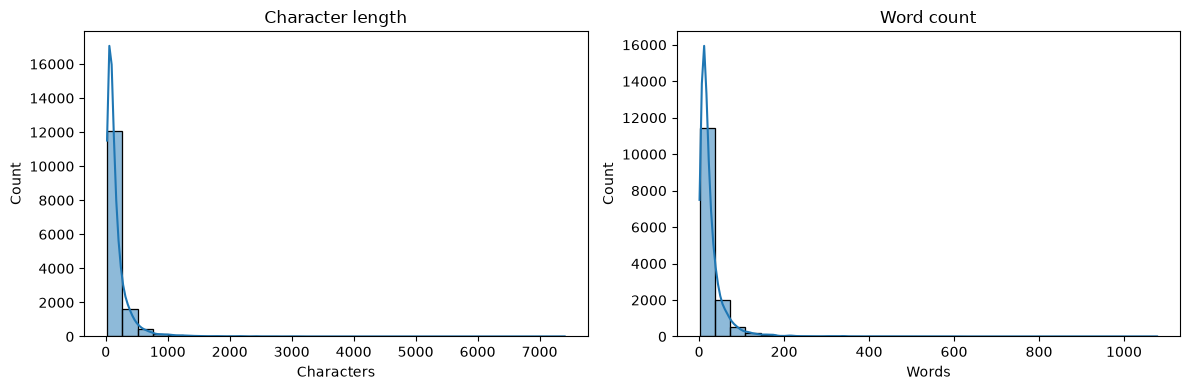

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["length"], bins=30, kde=True, ax=axes[0], edgecolor="black")
axes[0].set_title("Character length")
axes[0].set_xlabel("Characters")

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[1], edgecolor="black")
axes[1].set_title("Word count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [ ]:
print(df.groupby("label")["length"].describe()) # Grouped by classes

        count        mean         std   min   25%    50%    75%     max
label                                                                  
0      9586.0  194.213332  274.750067  21.0  66.0  118.0  223.0  7404.0
1      4826.0  141.392665  261.776417  21.0  45.0   76.0  140.0  5218.0


In [47]:
print(df.groupby("label")["word_count"].describe()) # Grouped by classes

        count       mean        std  min   25%   50%   75%     max
label                                                             
0      9586.0  30.713436  40.811415  2.0  11.0  19.0  36.0  1012.0
1      4826.0  22.449026  42.106674  1.0   7.0  12.0  23.0  1078.0


In [46]:
df['length'].quantile(0.999)

np.float64(3497.407999999996)

In [44]:
df[df['length'] > 3000]

,text,label,length,word_count
41,Ну давай разберём всё тобой написанное. Бляядь...,1,3455,550
214,"Раз уж вакханалия продолжается, давайте в этом...",0,4371,678
377,"в писанине указано, что Ссаколов реально не уп...",1,3389,495
471,"Не знаю, что он там вам показал, если вы не сп...",0,3082,467
486,"та ну, хуйня это все про джентельменство . мен...",0,3654,605
553,На одном из симпозиумов встретились четыре лин...,0,3752,493
659,"Знаете, моя подруга живёт с мужчиной, который ...",1,3928,676
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1,4214,666
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1,3805,598
1819,Чаще всего агрессия и агрессивность проявляетс...,1,3021,416


In [48]:
df['word_count'].quantile(0.999)

np.float64(500.8899999999994)

In [49]:
df[df['word_count'] > 500]

,text,label,length,word_count
41,Ну давай разберём всё тобой написанное. Бляядь...,1,3455,550
214,"Раз уж вакханалия продолжается, давайте в этом...",0,4371,678
486,"та ну, хуйня это все про джентельменство . мен...",0,3654,605
659,"Знаете, моя подруга живёт с мужчиной, который ...",1,3928,676
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1,4214,666
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1,3805,598
1953,"В Киеве на вокзале Мен було рок в 19, коли мен...",1,4921,1078
2064,С начала года свыше 40 тысяч россиян объявили ...,0,7404,1012
3016,"Блеаадь, как же обидно когда создаешь тред, па...",1,5218,787
5795,С 19 апреля в Николаеве будет действовать запр...,0,5174,741


## 4. Words top

In [ ]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r"[а-яёa-z]+", text.lower())

toxic_words = Counter(
    w for t in df[df["label"] == 1]["text"]
    for w in tokenize(t)
)
print("=== Top 30 toxic words ===")
for w, c in toxic_words.most_common(30):
    print(f"{w}: {c}")

neutral_words = Counter(
    w for t in df[df["label"] == 0]["text"]
    for w in tokenize(t)
)
print("\n=== Top 30 neutral words ===")
for w, c in neutral_words.most_common(30):
    print(f"{w}: {c}")

=== Top 30 toxic words ===
и: 3363
в: 2783
не: 2665
на: 1721
что: 1610
а: 1363
с: 1123
ты: 1076
это: 1057
то: 918
как: 916
я: 854
у: 795
по: 641
за: 614
так: 539
он: 535
же: 520
но: 448
все: 444
из: 404
бы: 389
к: 370
ну: 370
от: 363
просто: 361
да: 360
если: 355
его: 328
или: 326

=== Top 30 neutral words ===
и: 9323
в: 9203
не: 7636
на: 5282
что: 4376
а: 3655
с: 3182
это: 2913
то: 2847
как: 2345
я: 2319
но: 2255
по: 2225
у: 2116
так: 1766
за: 1717
если: 1556
все: 1418
из: 1221
к: 1219
для: 1198
же: 1146
от: 1119
есть: 1067
только: 1065
или: 1000
там: 967
вот: 900
можно: 891
было: 880


## 5. Duplicates

In [ ]:
dups = df[df.duplicated(subset=["text"], keep=False)]
print(f"Duplicates: {len(dups)} ({100*len(dups)/len(df):.2f}%)")

print("\nSample duplicates:")
for t in dups["text"].head(20):
    print(f"- {t}")

Duplicates: 0 (0.00%)

Sample duplicates:


: 

Матрица косинусной близости:

           кот        котёнок    кошка      стул       стульчик  
кот             1.000      0.918      1.000      0.395      0.246
котёнок         0.918      1.000      0.924      0.213      0.200
кошка           1.000      0.924      1.000      0.383      0.238
стул            0.395      0.213      0.383      1.000      0.932
стульчик        0.246      0.200      0.238      0.932      1.000


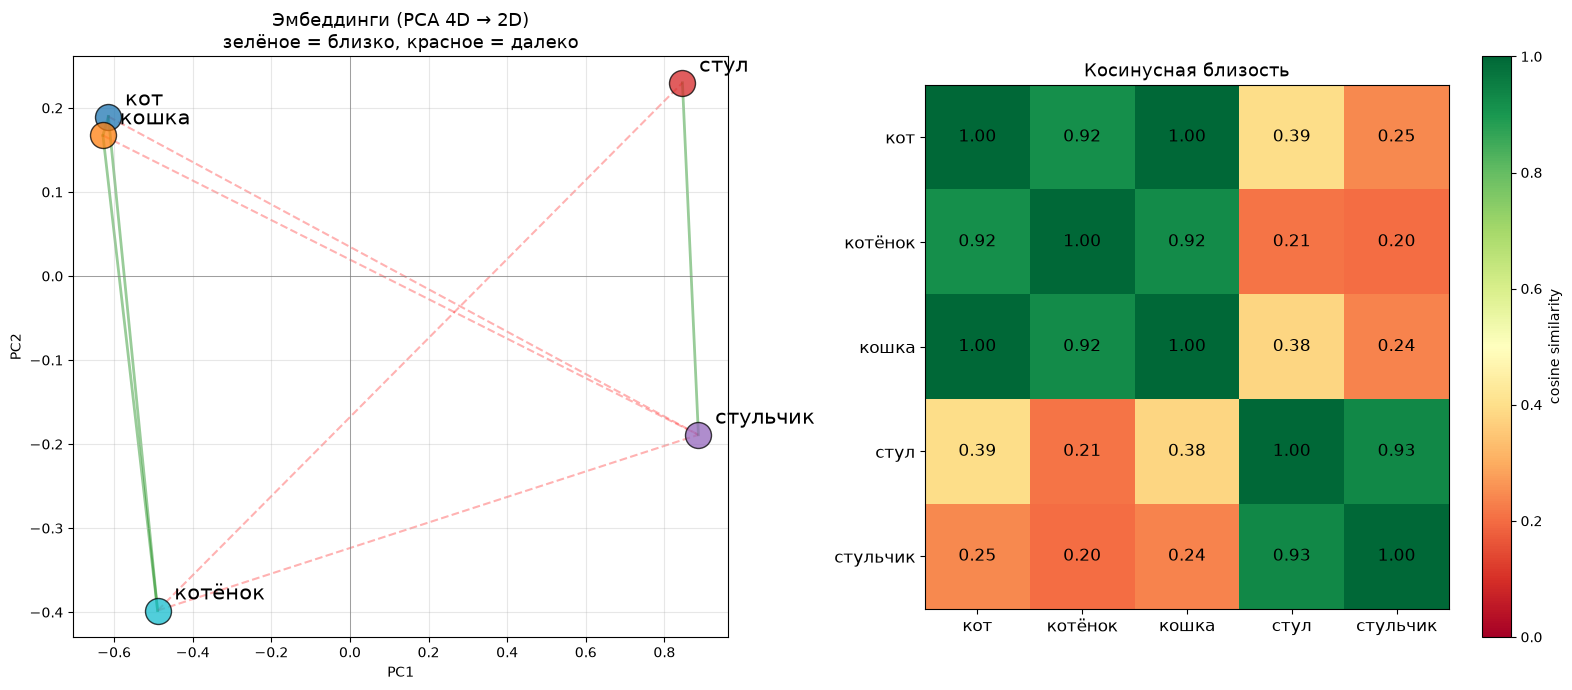

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.decomposition import PCA

# --- 1. Векторы токенов (4D, вручную заданы для наглядности) ---
# dim0: животное, dim1: домашнее, dim2: взрослость, dim3: мебель/предмет
embeddings = {
    "кот":      np.array([0.90, 0.85, 0.80, 0.05]),
    "котёнок":  np.array([0.88, 0.82, 0.20, 0.05]),
    "кошка":    np.array([0.91, 0.86, 0.78, 0.04]),
    "стул":     np.array([0.05, 0.10, 0.60, 0.95]),
    "стульчик": np.array([0.06, 0.12, 0.18, 0.93]),
}

words = list(embeddings.keys())
vectors = np.array([embeddings[w] for w in words])

# --- 2. Косинусная близость ---
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

n = len(words)
sim = np.array([[cosine(embeddings[w1], embeddings[w2])
                 for w2 in words] for w1 in words])

print("Матрица косинусной близости:\n")
print(f"{'':10}", *[f"{w:10}" for w in words])
for i, w in enumerate(words):
    print(f"{w:10}", *[f"{sim[i,j]:10.3f}" for j in range(n)])

# --- 3. Понижение размерности 4D → 2D через PCA ---
pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(vectors)

# --- 4. Визуализация: два графика рядом ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (а) точки в 2D
ax = axes[0]
colors = ["tab:blue", "tab:cyan", "tab:orange", "tab:red", "tab:purple"]
for i, word in enumerate(words):
    ax.scatter(vecs_2d[i, 0], vecs_2d[i, 1],
               s=350, alpha=0.75, color=colors[i],
               edgecolor='black', zorder=3)
    ax.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]),
                fontsize=15, xytext=(12, 8),
                textcoords='offset points', zorder=4)

# рисуем линии между парами с высокой/низкой близостью
for i, j in combinations(range(n), 2):
    if sim[i, j] > 0.7:
        ax.plot([vecs_2d[i,0], vecs_2d[j,0]],
                [vecs_2d[i,1], vecs_2d[j,1]],
                color='green', lw=2, alpha=0.4, zorder=1)
    elif sim[i, j] < 0.3:
        ax.plot([vecs_2d[i,0], vecs_2d[j,0]],
                [vecs_2d[i,1], vecs_2d[j,1]],
                color='red', lw=1.5, alpha=0.3,
                linestyle='--', zorder=1)

ax.set_title("Эмбеддинги (PCA 4D → 2D)\nзелёное = близко, красное = далеко",
             fontsize=13)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# (б) тепловая карта близости
ax = axes[1]
im = ax.imshow(sim, cmap='RdYlGn', vmin=0.0, vmax=1.0)
ax.set_xticks(range(n)); ax.set_xticklabels(words, fontsize=12)
ax.set_yticks(range(n)); ax.set_yticklabels(words, fontsize=12)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim[i,j]:.2f}",
                ha='center', va='center', fontsize=12,
                color='black')
ax.set_title("Косинусная близость", fontsize=13)
plt.colorbar(im, ax=ax, label='cosine similarity')

plt.tight_layout()
plt.show()